<a href="https://colab.research.google.com/github/cintiapinho/Aulas_FATEC_PLN/blob/main/Materiais/02_Introducao-ao-PLN/introducao_pln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sessão 02 — Primeiro contato com PLN em Python

**Processamento de Linguagem Natural**

Bloco de atividade (2 aulas) da sessão 02. Objetivo: sair deste notebook tendo tokenizado seu primeiro texto em português e entendido, na prática, por que "quebrar" um texto em palavras não é tão trivial quanto parece.

Leva menos de uma hora. Não precisa saber nada de PLN ainda — é só o primeiro contato.

## 1. Aquecendo com strings em Python

Antes de usar qualquer biblioteca de PLN, vale relembrar o que o Python puro já sabe fazer com texto — porque é exatamente daqui que a tokenização "por baixo dos panos" começa.

In [ ]:
frase = " Processamento de Linguagem Natural é incrível! "

In [ ]:
print(frase.lower())          # tudo minúsculo
print(frase.strip())          # tira espaços do início/fim
print(frase.replace("!", "")) # troca (ou remove) um trecho
print(len(frase))             # quantos caracteres tem
print(frase[2:16])            # fatiar (slicing): do caractere 2 até o 15

 processamento de linguagem natural é incrível! 
Processamento de Linguagem Natural é incrível!
 Processamento de Linguagem Natural é incrível 
48
rocessamento d


Uma string também é uma sequência — dá pra fatiar (`frase[2:16]`) e, mais importante pra hoje, dá pra **quebrar em pedaços** com `.split()`. Isso já é, no fundo, uma primeira tentativa de tokenização.

In [ ]:
frase_simples = "Python é uma linguagem de programação. PLN é incrível! Mas também é desafiador, não é mesmo?"
print(frase_simples.split('.'))

['Python é uma linguagem de programação', ' PLN é incrível! Mas também é desafiador, não é mesmo?']


Funcionou bem — pra essa frase. Mas repare o que acontece com uma frase mais realista, com pontuação:

In [ ]:
frase_real = "PLN é incrível! Mas também é desafiador, não é mesmo?"
print(frase_real.split())

['PLN', 'é', 'incrível!', 'Mas', 'também', 'é', 'desafiador,', 'não', 'é', 'mesmo?']


Repare que a pontuação ficou grudada nas palavras (`"incrível!"`, `"mesmo?"`) — `.split()` só separa por espaço, não sabe nada sobre gramática. É exatamente esse tipo de problema que uma biblioteca feita para PLN resolve. Vamos ver como.

### Indexação, com mais detalhe

Cada caractere de uma string tem uma posição — inclusive de trás pra frente, com índice negativo:

In [ ]:
s = "Fatec Mauá"

print(s[0])    # primeiro caractere
print(s[1])    # segundo caractere
print(s[-1])   # último caractere (índice negativo)
print(s[:-1])  # tudo, menos o último caractere

F
a
á
Fatec Mau


O `:` do slicing também aceita um terceiro número — o passo. Passo `-1` é um jeito rápido de inverter a string inteira:

In [ ]:
print(s[::1])   # passo 1 — igual ao original, sem pular nada
print(s[::2])   # passo 2 — pula um caractere a cada vez
print(s[::-1])  # passo -1 — percorre de trás pra frente: inverte a string

Fatec Mauá
FtcMu
áuaM cetaF


Duas strings também se combinam com operadores que você já conhece de número: `+` junta (concatena) duas strings numa só, e `*` repete uma string várias vezes. Isso é muito usado, por exemplo, pra montar uma linha separadora ou juntar nome e sobrenome:

In [ ]:
curso = "Processamento de Linguagem Natural"

print(s + " — " + curso)  # + concatena (junta) as strings

separador = "-" * 20      # * repete a string 20 vezes
print(separador)

Fatec Mauá — Processamento de Linguagem Natural
--------------------


### Mais funções prontas de string

Além de `.lower()`, `.strip()` e `.replace()` que você já viu, o Python tem várias outras funções embutidas pra responder perguntas sobre uma string — muitas delas devolvem `True`/`False` (perguntas de sim ou não) ou uma posição/contagem:

In [ ]:
frase = "seja bem vindo ao universo de python"

print(frase.capitalize())    # deixa só a primeira letra maiúscula
print(frase.count("o"))      # conta quantas vezes "o" aparece
print(frase.find("python"))  # em que posição "python" começa (-1 se não achar)
print(frase.isalpha())       # é feita só de letras, sem espaço nem número?
print(frase.islower())       # está toda em minúsculo?
print(frase.endswith("n"))   # termina com "n"?

Seja bem vindo ao universo de python
4
30
False
True
True


Repare que `frase.isalpha()` deu `False` — a frase inteira tem espaços entre as palavras, e espaço não é letra. `.isalpha()` só devolve `True` quando *todos* os caracteres da string são letras, sem exceção. Guarde essa ideia: é exatamente o que vamos usar mais tarde pra filtrar pontuação de uma lista de tokens.

### Comparando strings

Strings também podem ser comparadas com `==`, igual números — e maiúsculo/minúsculo faz diferença:

In [ ]:
print("Python" == "python")  # False — maiúscula/minúscula importa na comparação
print("Python" == "Python")  # True — idênticas

False
True


## 2. Preparando o ambiente

Vamos usar o `NLTK` (Natural Language Toolkit), a biblioteca mais didática de PLN em Python. Se estiver rodando no Google Colab, o NLTK já vem instalado; se estiver na sua máquina, rode a célula abaixo uma vez.

In [ ]:
# Se necessário, descomente a linha abaixo para instalar o NLTK
!pip install nltk

import nltk

# Baixa os recursos usados para tokenizar (só precisa rodar uma vez por máquina)
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 3. Nosso primeiro texto

Vamos trabalhar com uma avaliação de produto em português — o mesmo tipo de texto que você vai ver de novo lá na frente, quando chegarmos em análise de sentimento.

In [ ]:
texto = (
    "Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto. "
    "A bateria dura o dia inteiro. o som é ótimo pra esse preço e o app conectou super rápido. "
    "Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência. Recomendo!"
)

print(texto)

Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto. A bateria dura o dia inteiro. o som é ótimo pra esse preço e o app conectou super rápido. Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência. Recomendo!


In [ ]:
texto

'Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto. A bateria dura o dia inteiro. o som é ótimo pra esse preço e o app conectou super rápido. Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência. Recomendo!'

In [ ]:
type(texto)

str

## 4. Segmentação de sentenças

Antes de quebrar em palavras, vamos quebrar em frases. Parece simples ("é só separar pelo ponto final"), mas repare que o texto tem abreviações e números — um separador ingênuo por `.` erraria em vários lugares reais (ex.: "Sr.", "3.5", "www.site.com").

In [ ]:
from nltk.tokenize import sent_tokenize

sentencas = sent_tokenize(texto, language='portuguese')
sentencas



['Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto.',
 'A bateria dura o dia inteiro.',
 'o som é ótimo pra esse preço e o app conectou super rápido.',
 'Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência.',
 'Recomendo!']

In [ ]:
type(sentencas)

list

In [ ]:
for i, s in enumerate(sentencas, start=1):
    print(f"{i}. {s}")

1. Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto.
2. A bateria dura o dia inteiro.
3. o som é ótimo pra esse preço e o app conectou super rápido.
4. Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência.
5. Recomendo!


## 5. Tokenização de palavras

Agora quebramos cada sentença em tokens (palavras e pontuação separadas), com uma ferramenta feita pra isso — repare como ela lida melhor com a pontuação do que o `.split()` lá de cima. Note também como "não", "é" e a pontuação viram itens próprios da lista — isso é o tipo de detalhe que vamos aprender a tratar (ou não) na sessão 3.

*Isso é literalmente o nível mais básico da "hierarquia da compreensão" que vimos no material teórico — o nível morfológico: decidir quais são as unidades (as palavras) antes de qualquer análise mais profunda.*

In [ ]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(texto, language='portuguese')



In [ ]:
tokens

['Comprei',
 'esse',
 'fone',
 'de',
 'ouvido',
 'semana',
 'passada',
 'e',
 ',',
 'sinceramente',
 ',',
 'não',
 'esperava',
 'tanto',
 '.',
 'A',
 'bateria',
 'dura',
 'o',
 'dia',
 'inteiro',
 '.',
 'o',
 'som',
 'é',
 'ótimo',
 'pra',
 'esse',
 'preço',
 'e',
 'o',
 'app',
 'conectou',
 'super',
 'rápido',
 '.',
 'Só',
 'achei',
 'a',
 'caixinha',
 'um',
 'pouco',
 'frágil',
 ',',
 'mas',
 'isso',
 'não',
 'estragou',
 'minha',
 'experiência',
 '.',
 'Recomendo',
 '!']

In [ ]:
print(f"Total de tokens: {len(tokens)}")
print(tokens)

Total de tokens: 53
['Comprei', 'esse', 'fone', 'de', 'ouvido', 'semana', 'passada', 'e', ',', 'sinceramente', ',', 'não', 'esperava', 'tanto', '.', 'A', 'bateria', 'dura', 'o', 'dia', 'inteiro', '.', 'o', 'som', 'é', 'ótimo', 'pra', 'esse', 'preço', 'e', 'o', 'app', 'conectou', 'super', 'rápido', '.', 'Só', 'achei', 'a', 'caixinha', 'um', 'pouco', 'frágil', ',', 'mas', 'isso', 'não', 'estragou', 'minha', 'experiência', '.', 'Recomendo', '!']


## 6. Quais palavras mais aparecem?

Vamos contar a frequência de cada token. Antes de rodar, tente prever: quais palavras você acha que vão aparecer mais nesse texto?

In [ ]:
from collections import Counter

# Normalizamos para minúsculas antes de contar, senão "O" e "o" contariam como palavras diferentes

tokens_normalizados = [t.lower() for t in tokens]
print(tokens_normalizados)

frequencia = Counter(tokens_normalizados)
print(frequencia)



['comprei', 'esse', 'fone', 'de', 'ouvido', 'semana', 'passada', 'e', ',', 'sinceramente', ',', 'não', 'esperava', 'tanto', '.', 'a', 'bateria', 'dura', 'o', 'dia', 'inteiro', '.', 'o', 'som', 'é', 'ótimo', 'pra', 'esse', 'preço', 'e', 'o', 'app', 'conectou', 'super', 'rápido', '.', 'só', 'achei', 'a', 'caixinha', 'um', 'pouco', 'frágil', ',', 'mas', 'isso', 'não', 'estragou', 'minha', 'experiência', '.', 'recomendo', '!']
Counter({'.': 4, ',': 3, 'o': 3, 'esse': 2, 'e': 2, 'não': 2, 'a': 2, 'comprei': 1, 'fone': 1, 'de': 1, 'ouvido': 1, 'semana': 1, 'passada': 1, 'sinceramente': 1, 'esperava': 1, 'tanto': 1, 'bateria': 1, 'dura': 1, 'dia': 1, 'inteiro': 1, 'som': 1, 'é': 1, 'ótimo': 1, 'pra': 1, 'preço': 1, 'app': 1, 'conectou': 1, 'super': 1, 'rápido': 1, 'só': 1, 'achei': 1, 'caixinha': 1, 'um': 1, 'pouco': 1, 'frágil': 1, 'mas': 1, 'isso': 1, 'estragou': 1, 'minha': 1, 'experiência': 1, 'recomendo': 1, '!': 1})


In [ ]:
for palavra, contagem in frequencia.most_common(10):
    print(f"{palavra!r}: {contagem}")

'.': 4
',': 3
'o': 3
'esse': 2
'e': 2
'não': 2
'a': 2
'comprei': 1
'fone': 1
'de': 1


Repare que o topo da lista tem dois tipos de "ruído" bem diferentes, que **não** são a mesma coisa:

- **Pontuação** — `,` e `.`. Não são palavras, são separadores que a tokenização manteve como itens da lista.
- **Palavras funcionais muito frequentes** — "o", "e", "a". Essas sim são *stopwords*: palavras que aparecem em praticamente qualquer texto em português e dizem pouco sobre o *conteúdo* dele.

São dois problemas diferentes, com soluções diferentes: pontuação a gente filtra (por exemplo, mantendo só tokens alfabéticos), stopwords a gente remove com uma lista pronta. Vamos tratar os dois na sessão 3.

## 7. Visualizando a frequência

Um gráfico simples ajuda a enxergar o padrão.

In [ ]:
!pip install matplotlib

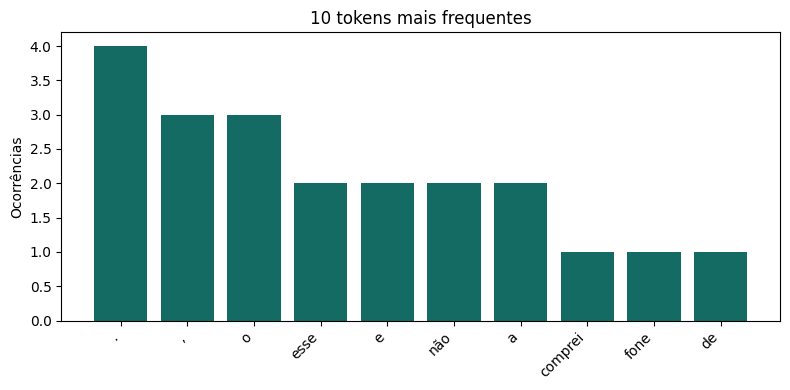

In [ ]:

import matplotlib.pyplot as plt

mais_comuns = frequencia.most_common(10)
palavras = [p for p, _ in mais_comuns]
contagens = [c for _, c in mais_comuns]

plt.figure(figsize=(8, 4))
plt.bar(palavras, contagens, color='#146B63')
plt.title('10 tokens mais frequentes')
plt.ylabel('Ocorrências')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Sua vez

Troque a variável `texto` da seção 3 por um parágrafo curto escrito por você (ou copiado de uma notícia, rede social, etc. — em português) e rode as células de novo.

**Entregue como atividade (2–3 frases cada resposta, na célula de markdown abaixo):**

1. Alguma palavra foi tokenizada de um jeito que te surpreendeu? Qual e por quê?
2. Se você tivesse que apagar as palavras menos úteis da lista de frequência antes de analisar o *assunto* do texto, quais tiraria primeiro?
3. Pensando na lista de frequência da seção 6: como você faria, em código, para tirar a pontuação e as stopwords antes de contar? Não precisa implementar — descreva a ideia. Dica: o que você perguntaria sobre cada token para decidir se ele fica ou sai da lista?

> **Dicas, se travar:**
> - Para pontuação: existe uma forma de perguntar "esse token é feito só de letras?" para cada item — pesquise `str.isalpha()` em Python.
> - Para stopwords: você não precisa escrever a lista de palavras vazias na mão — o NLTK já tem uma pronta para português, em `nltk.corpus.stopwords`.
> - No fim, as duas soluções são a mesma ideia: montar uma nova lista de tokens que só inclui quem "passa no teste", e só depois contar a frequência dela.
>
> A implementação completa a gente faz junto na sessão 3 — aqui o objetivo é só chegar perto da ideia sozinho(a).

In [ ]:
teste = "olá eu tenho 20 anos e tenho 1,75m de altura. Meu peso é 70kg e meu IMC é 22,9. Meu CPF é 123.456.789-00 e meu RG é 12.345.678-9."

In [ ]:
str.isalpha(teste)

> ## Lembre

> E se depois que você tokenizar o texto verificar se ele é de fato uma letra? caso for um ponto, número ou interrogação por exemplo, você pode ignorar.






In [ ]:
nltk.download('stopwords')
print(nltk.corpus.stopwords.words('portuguese'))

> #### E se você quiser excluir essas palavras, para que elas não sejam contadas como frequentes? como você faria?



## Então agora é com você!!

In [ ]:
meu_texto = "Escreva aqui o seu próprio texto em português..."

meus_tokens = word_tokenize(meu_texto, language='portuguese')
print(meus_tokens)

['Escreva', 'aqui', 'o', 'seu', 'próprio', 'texto', 'em', 'português', '...']


**Suas respostas:**

1. _(escreva aqui)_
2. _(escreva aqui)_

## 9. Pra praticar mais: manipulação de strings

Dez exercícios curtos pra fixar o que vimos na seção 1. Não precisa ser em ordem — crie uma célula de código nova abaixo de cada um pra resolver, e pode consultar os exemplos lá de cima sempre que precisar.

1. Crie uma variável com seu nome completo e imprima quantos caracteres ela tem (dica: `len()`).
2. A partir do seu nome completo, imprima só os 3 primeiros caracteres.
3. Imprima seu nome completo todo em letras maiúsculas, e depois todo em minúsculas.
4. Dada a frase `frase = "A aula de PLN é aos sábados"`, conte quantas vezes a letra "a" aparece (maiúscula e minúscula contam separado).
5. Separe essa mesma frase numa lista de palavras, usando `.split()`.
6. Junte (concatene) seu nome com o texto `" - Fatec Mauá"` numa nova variável, e imprima o resultado.
7. Crie uma variável com uma palavra curta e imprima ela repetida 5 vezes, separada por hífen (dica: combine `*` com um separador, ou pesquise `.join()`).
8. Dada a frase `frase = "PLN é o futuro da tecnologia"`, descubra em que posição a palavra "futuro" começa (dica: `.find()`).
9. Verifique se a string `"python3"` é composta só por letras com `.isalpha()`. O resultado é `True` ou `False`? Por quê?
10. A variável `bagunçada = "  Fatec   Mauá  "` tem espaços extras no início, no fim, e duplicados entre as palavras. Deixe ela limpa, assim: `"Fatec Mauá"` (dica: `.strip()` sozinho não resolve os espaços do meio — combine com `.split()` e `" ".join()`).